# Aegis Nexus — Technical Appendix: CLV & Unit Economics

**Course**: RSM 8542 Analytics for Marketing Strategy (Spring 2026)  
**Deliverable**: Individual Project — Technical Appendix  

This notebook implements a simulated **Customer Lifetime Value (CLV) and unit economics** analysis for **Aegis Nexus**, an AI-enabled cloud gaming asset-streaming platform. Unlike full-game cloud streaming services (e.g., GeForce NOW, Xbox Cloud Gaming) that render the entire game on remote servers, Aegis Nexus runs game logic locally on the player's device and streams only graphical assets (textures, audio, geometry) on demand. This dramatically reduces installation size — enabling instant play on mid-range smartphones and large-storage PC titles without requiring high-end local hardware or full file downloads. Because the product has not yet launched, all user data is synthetic and generated from an explicitly stated data-generating process (DGP).

The notebook serves three deliverables simultaneously:

1. **Technical appendix** for the final report — code, outputs, and reproducibility documentation
2. **Analytics exhibits** — all figures and tables used in the written launch plan's analytics section
3. **Presentation scorecard** — one export-ready visual summarising the key quantitative recommendation

---

## Reproducibility Note

| Item | Detail |
|---|---|
| Language | Python 3.10+ |
| Required packages | `numpy`, `pandas`, `matplotlib`, `seaborn` |
| Random seed | `42` (fixed at top of Cell 0; never changes) |
| Run order | **Top to bottom, all cells, once** — each section depends on variables defined above it |
| Outputs | All figures and CSV tables are saved automatically to `outputs/` |

**Method summary**: CLV is estimated as *discounted contribution-margin CLV* (not revenue-only CLV). Monthly contribution margin = monthly price − monthly infrastructure cost. This formulation directly supports actionable launch decisions: the maximum sustainable CAC equals CLV, and the payback period is the month at which cumulative discounted margin first exceeds CAC.

In [ ]:
# ── Cell 0: Imports, random seed, display config, output directory ─────────────
# Run this cell first. Everything else depends on it.

import math
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')  # suppress minor version warnings

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Output directory (absolute path) ──────────────────────────────────────────
OUTPUT_DIR = r'D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Brand colour palette (used consistently across all charts) ────────────────
PALETTE = {
    'navy'  : '#1a3a5c',   # deep navy  — primary headers / key annotations
    'steel' : '#2c5f8a',   # steel blue — Basic tier / primary bars
    'gold'  : '#d4860b',   # amber gold — Premium tier / accent
    'teal'  : '#2a9d8f',   # teal       — secondary / upside scenarios
    'rose'  : '#c0392b',   # crimson    — warnings / reference lines / downside
    'lgrey' : '#e8edf2',   # light grey — alternate row fills
    'dgrey' : '#6b7280',   # dark grey  — annotations / footnotes
}
TIER_COLORS = {'Basic': PALETTE['steel'], 'Premium': PALETTE['gold']}

# ── Presentation-ready global rcParams ────────────────────────────────────────
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize'      : (12, 7),
    'figure.dpi'          : 120,
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.spines.left'    : True,
    'axes.spines.bottom'  : True,
    'axes.edgecolor'      : '#cccccc',
    'axes.labelcolor'     : '#333333',
    'axes.titlecolor'     : '#1a1a2e',
    'axes.titlesize'      : 14,
    'axes.titleweight'    : 'bold',
    'axes.labelsize'      : 11,
    'axes.grid'           : True,
    'grid.color'          : '#e0e0e0',
    'grid.linewidth'      : 0.6,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'xtick.color'         : '#555555',
    'ytick.color'         : '#555555',
    'legend.fontsize'     : 10,
    'legend.framealpha'   : 0.9,
    'legend.edgecolor'    : '#cccccc',
    'font.family'         : 'sans-serif',
    'savefig.dpi'         : 200,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
})

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)

print(f'Random seed : {SEED}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print(f'Matplotlib  : {plt.matplotlib.__version__}')
print(f'Seaborn     : {sns.__version__}')

: 

---
## 1. Assumptions

All top-level parameters are defined in a single cell below. **Edit values here** to re-run the full analysis under alternative assumptions without touching any other cell.

Parameter choices are based on the project proposal and informed by analogous subscription gaming platforms (e.g., Xbox Game Pass, GeForce NOW). See the written report for full justification.

In [2]:
# ── Cell 1: Top-level assumptions (EDIT HERE) ──────────────────────────────────

# ── Simulation scale ──────────────────────────────────────────────────────────
N_USERS              = 100_000   # synthetic users to simulate
MONTHLY_DISCOUNT_RATE = 0.01     # 1% per month ≈ 12.7% annually (risk-adjusted)
PAYBACK_HORIZON_MONTHS = 36      # maximum months to evaluate payback

# ── Subscription tiers: mix and monthly price ──────────────────────────────────
# Basic  = standard streaming quality, lower cloud resource priority
# Premium = higher fidelity, priority cloud access
tier_mix = {
    'Basic'  : 0.72,   # 72% of users adopt the Basic tier at launch
    'Premium': 0.28,   # 28% adopt Premium (conservative early-adoption estimate)
}

tier_price = {
    'Basic'  : 11.99,  # USD/month
    'Premium': 18.99,  # USD/month
}

# ── Activity levels: share of user base ───────────────────────────────────────
# Activity drives infrastructure cost and correlates with retention.
activity_mix = {
    'Light' : 0.35,   # casual gamers, <5 hrs/week
    'Medium': 0.45,   # regular gamers, 5–15 hrs/week
    'Heavy' : 0.20,   # core gamers, >15 hrs/week
}

# ── Monthly retention probabilities by segment ─────────────────────────────────
# Each cell is the mean retention for that tier × activity combination.
# Heavy users churn less because the platform is more embedded in their routine.
base_retention = {
    ('Basic',   'Light') : 0.79,
    ('Basic',   'Medium'): 0.84,
    ('Basic',   'Heavy') : 0.88,
    ('Premium', 'Light') : 0.83,
    ('Premium', 'Medium'): 0.88,
    ('Premium', 'Heavy') : 0.92,
}

# Individual-level noise around the segment mean
retention_sd = {
    'Light' : 0.020,
    'Medium': 0.018,
    'Heavy' : 0.015,
}

# ── Customer acquisition cost (CAC) by tier ────────────────────────────────────
# Premium users are more expensive to acquire (higher-intent ad formats, etc.)
cac_mean = {'Basic': 27.0, 'Premium': 35.0}   # USD
cac_sd   = {'Basic':  6.0, 'Premium':  7.5}   # USD

# ── Monthly cloud infrastructure cost per user ─────────────────────────────────
# Driven by data transfer and compute. Heavy users stream more, cost more.
infra_cost_mean = {
    ('Basic',   'Light') : 3.0,
    ('Basic',   'Medium'): 4.6,
    ('Basic',   'Heavy') : 6.4,
    ('Premium', 'Light') : 4.8,
    ('Premium', 'Medium'): 6.8,
    ('Premium', 'Heavy') : 9.4,
}

infra_cost_sd = {
    'Light' : 0.45,
    'Medium': 0.65,
    'Heavy' : 0.90,
}

# ── Summary of base-case settings ─────────────────────────────────────────────
assumption_table = pd.DataFrame({
    'Setting': [
        'Sample size',
        'Monthly discount rate',
        'Payback evaluation horizon',
        'Premium tier share',
        'Basic monthly price',
        'Premium monthly price',
        'Mean CAC — Basic',
        'Mean CAC — Premium',
    ],
    'Value': [
        f'{N_USERS:,}',
        f'{MONTHLY_DISCOUNT_RATE:.1%} / month',
        f'{PAYBACK_HORIZON_MONTHS} months',
        f"{tier_mix['Premium']:.0%}",
        f"${tier_price['Basic']:.2f}",
        f"${tier_price['Premium']:.2f}",
        f"${cac_mean['Basic']:.0f}",
        f"${cac_mean['Premium']:.0f}",
    ],
    'Rationale': [
        'Sufficient for stable CLV estimates across 6 segments',
        'Approx. 12.7% annually; reflects early-stage risk',
        '3-year window captures most of the retention tail',
        'Conservative; premium mix may rise after content library grows',
        'Competitive with Xbox Game Pass Core (~$9.99) plus streaming premium',
        'Aligned with GeForce NOW Priority (~$19.99)',
        'Mobile gaming UA benchmarks (AppsFlyer 2024)',
        'Higher-intent formats (playable ads) carry premium CPIs',
    ],
})

display(assumption_table)

,Setting,Value,Rationale
0,Sample size,"100,000",Sufficient for stable CLV estimates across 6 s...
1,Monthly discount rate,1.0% / month,Approx. 12.7% annually; reflects early-stage risk
2,Payback evaluation horizon,36 months,3-year window captures most of the retention tail
3,Premium tier share,28%,Conservative; premium mix may rise after conte...
4,Basic monthly price,$11.99,Competitive with Xbox Game Pass Core (~$9.99) ...
5,Premium monthly price,$18.99,Aligned with GeForce NOW Priority (~$19.99)
6,Mean CAC — Basic,$27,Mobile gaming UA benchmarks (AppsFlyer 2024)
7,Mean CAC — Premium,$35,Higher-intent formats (playable ads) carry pre...


---
## 2. Synthetic Data-Generating Process

Users are drawn from a **2 × 3 segment grid** (tier × activity level). Within each cell, individual-level values for retention probability, CAC, and infrastructure cost are drawn from truncated Normal distributions around segment-specific means. This produces realistic heterogeneity — not every user in a segment behaves identically — while keeping the simulation fully transparent and reproducible.

**Vectorised implementation**: all random draws are made in a single NumPy call per variable (no row-wise `apply` loops), keeping runtime under one second for 100 k users.

In [3]:
# ── Cell 2: Synthetic data generation (vectorised) ─────────────────────────────

# Step 1 — Assign tier and activity level from their respective distributions.
# rng.choice respects the probability weights in tier_mix / activity_mix.
users = pd.DataFrame({
    'user_id'           : np.arange(1, N_USERS + 1),
    'subscription_tier' : rng.choice(
        list(tier_mix.keys()), size=N_USERS, p=list(tier_mix.values())
    ),
    'activity_level'    : rng.choice(
        list(activity_mix.keys()), size=N_USERS, p=list(activity_mix.values())
    ),
})

# Map deterministic price to each user based on their tier
users['monthly_price'] = users['subscription_tier'].map(tier_price)

# Step 2 — Build per-user mean/sd arrays by looking up segment keys.
# This avoids row-wise apply() and is ~40× faster for 100 k rows.
tier_arr = users['subscription_tier'].to_numpy()
act_arr  = users['activity_level'].to_numpy()

ret_mean_arr   = np.array([base_retention[(t, a)] for t, a in zip(tier_arr, act_arr)])
ret_sd_arr     = np.array([retention_sd[a]         for a in act_arr])
cac_mean_arr   = np.array([cac_mean[t]             for t in tier_arr])
cac_sd_arr     = np.array([cac_sd[t]               for t in tier_arr])
infra_mean_arr = np.array([infra_cost_mean[(t, a)] for t, a in zip(tier_arr, act_arr)])
infra_sd_arr   = np.array([infra_cost_sd[a]        for a in act_arr])

# Step 3 — Draw all stochastic variables in one vectorised call each.
# Clipping enforces meaningful bounds:
#   retention: [0.65, 0.97]  — no segment churn > 35%/month or stay > 97%
#   cac:       [8.00, ∞)     — floor at $8 (minimum viable ad spend)
#   infra:     [1.00, ∞)     — floor at $1 (irreducible cloud overhead)
users['monthly_retention_prob']    = np.clip(rng.normal(ret_mean_arr,   ret_sd_arr),   0.65, 0.97)
users['cac']                       = np.clip(rng.normal(cac_mean_arr,   cac_sd_arr),   8.00, None)
users['monthly_infrastructure_cost'] = np.clip(rng.normal(infra_mean_arr, infra_sd_arr), 1.00, None)

# ── Preview ───────────────────────────────────────────────────────────────────
print(f'Dataset: {len(users):,} users × {users.shape[1]} variables')
users.head()

Dataset: 100,000 users × 7 variables


,user_id,subscription_tier,activity_level,monthly_price,monthly_retention_prob,cac,monthly_infrastructure_cost
0,1,Premium,Heavy,18.99,0.92,43.37,7.33
1,2,Basic,Heavy,11.99,0.88,35.27,6.88
2,3,Premium,Medium,18.99,0.87,46.17,5.95
3,4,Basic,Light,11.99,0.81,20.52,2.46
4,5,Basic,Medium,11.99,0.84,34.02,3.65


---
## 3. Validation Checks

Before using the simulated data for any decisions, verify that it is internally consistent and that the intended segment structure has been reproduced. A simulation that fails basic sanity checks would invalidate all downstream outputs.

In [4]:
# ── Cell 3: Validation checks ─────────────────────────────────────────────────

# ── 3a. Bounds checks ─────────────────────────────────────────────────────────
obs_premium_share = users['subscription_tier'].eq('Premium').mean()

validation = pd.DataFrame({
    'Check': [
        'All retention probabilities in [0, 1]',
        'All monthly prices > 0',
        'All CAC values > 0',
        'All infrastructure costs > 0',
        'Observed Premium share within ±2 pp of target (28%)',
    ],
    'Result': [
        users['monthly_retention_prob'].between(0, 1).all(),
        (users['monthly_price'] > 0).all(),
        (users['cac'] > 0).all(),
        (users['monthly_infrastructure_cost'] > 0).all(),
        abs(obs_premium_share - tier_mix['Premium']) < 0.02,
    ],
    'Detail': [
        f"min={users['monthly_retention_prob'].min():.3f}, max={users['monthly_retention_prob'].max():.3f}",
        f"min=${users['monthly_price'].min():.2f}",
        f"min=${users['cac'].min():.2f}",
        f"min=${users['monthly_infrastructure_cost'].min():.2f}",
        f"observed={obs_premium_share:.1%}, target={tier_mix['Premium']:.1%}",
    ],
})
display(validation)

# ── 3b. Segment mix ────────────────────────────────────────────────────────────
# Verify that the simulated tier × activity shares match the intended DGP
segment_mix = (
    users
    .groupby(['subscription_tier', 'activity_level'])
    .size()
    .rename('users')
    .reset_index()
)
segment_mix['observed_share'] = segment_mix['users'] / len(users)
# Expected share = tier_mix × activity_mix (independent draws)
segment_mix['expected_share'] = segment_mix.apply(
    lambda r: tier_mix[r['subscription_tier']] * activity_mix[r['activity_level']], axis=1
)
segment_mix['diff_pp'] = (segment_mix['observed_share'] - segment_mix['expected_share']) * 100
print('\nSegment mix (observed vs expected):')
display(segment_mix.round(4))

# ── 3c. Retention ordering sanity check ───────────────────────────────────────
# Heavy-activity users should retain better than Light-activity users within
# each tier. If this fails the DGP itself is misconfigured.
for tier in ['Basic', 'Premium']:
    light_ret = users.loc[
        (users.subscription_tier == tier) & (users.activity_level == 'Light'),
        'monthly_retention_prob'
    ].mean()
    heavy_ret = users.loc[
        (users.subscription_tier == tier) & (users.activity_level == 'Heavy'),
        'monthly_retention_prob'
    ].mean()
    assert heavy_ret > light_ret, (
        f'FAIL: Heavy retention ({heavy_ret:.3f}) < Light retention ({light_ret:.3f}) for {tier}'
    )
    print(f'{tier}: Light retention = {light_ret:.3f}, Heavy retention = {heavy_ret:.3f}  ✓')

print('\nAll validation checks passed.')

,Check,Result,Detail
0,"All retention probabilities in [0, 1]",True,"min=0.708, max=0.970"
1,All monthly prices > 0,True,min=$11.99
2,All CAC values > 0,True,min=$8.00
3,All infrastructure costs > 0,True,min=$1.11
4,Observed Premium share within ±2 pp of target ...,True,"observed=28.0%, target=28.0%"



Segment mix (observed vs expected):


,subscription_tier,activity_level,users,observed_share,expected_share,diff_pp
0,Basic,Heavy,14456,0.14,0.14,0.06
1,Basic,Light,25364,0.25,0.25,0.16
2,Basic,Medium,32173,0.32,0.32,-0.23
3,Premium,Heavy,5525,0.06,0.06,-0.07
4,Premium,Light,9769,0.10,0.10,-0.03
5,Premium,Medium,12713,0.13,0.13,0.11


Basic: Light retention = 0.790, Heavy retention = 0.880  ✓
Premium: Light retention = 0.830, Heavy retention = 0.920  ✓

All validation checks passed.


---
## 4. CLV Model and Unit Economics

### Methodology

The notebook uses **discounted contribution-margin CLV** under a constant-retention Markov model. For user $i$, CLV is the expected present value of all future monthly contribution margins:

$$
\text{CLV}_i = \sum_{t=1}^{\infty} m_i \cdot \left(\frac{r_i}{1+d}\right)^{t-1}
= \frac{m_i}{1 - \dfrac{r_i}{1+d}}
$$

| Symbol | Definition |
|---|---|
| $m_i$ | Monthly contribution margin = `monthly_price` − `monthly_infrastructure_cost` |
| $r_i$ | Monthly retention probability (individual-level) |
| $d$   | Monthly discount rate (1%; set in assumptions cell) |

This is the closed-form infinite-horizon geometric series — appropriate because no upper lifetime cap is assumed ex ante.

**Why contribution-margin CLV, not revenue CLV?**  
Revenue CLV overstates the value available to fund acquisition. Infrastructure cost is real and variable; ignoring it would make the maximum sustainable CAC look larger than it is, producing over-spending at launch.

### Payback period

Payback is the first month $T^*$ at which cumulative discounted margin equals or exceeds CAC:

$$
T^* = \min \left\{ T : \sum_{t=1}^{T} m_i \cdot \left(\frac{r_i}{1+d}\right)^{t-1} \geq \text{CAC}_i \right\}
$$

Two implementations are provided and cross-checked:
- **Loop-based** (`payback_months`): exact, iterates month-by-month
- **Closed-form** (`payback_approx`): solves the geometric series inequality analytically

In [5]:
# ── Cell 4a: Helper functions ──────────────────────────────────────────────────

def discounted_clv(monthly_margin, monthly_retention, monthly_discount):
    """
    Closed-form infinite-horizon discounted contribution-margin CLV.

    Parameters
    ----------
    monthly_margin    : array-like, USD — price minus infra cost per user per month
    monthly_retention : array-like, probability [0, 1]
    monthly_discount  : float — monthly discount rate (e.g. 0.01 for 1%)

    Returns
    -------
    CLV in USD (same shape as inputs)
    """
    survival_factor = monthly_retention / (1 + monthly_discount)
    return monthly_margin / (1 - survival_factor)


def expected_lifetime_months(monthly_retention):
    """
    Expected number of months a user stays active under a geometric churn model.
    E[T] = 1 / (1 - r) where r is monthly retention probability.
    """
    return 1 / (1 - monthly_retention)


def discounted_payback_months(monthly_margin, monthly_retention, cac,
                               monthly_discount, horizon):
    """
    Exact (loop-based) discounted payback period.
    Returns the first month T at which cumulative discounted margin >= cac.
    Returns NaN if payback is not reached within `horizon` months.

    Complexity: O(n × horizon). For 100k users and 36 months, this is fast enough.
    """
    ds         = monthly_retention / (1 + monthly_discount)   # discount-survival factor
    cumulative = np.zeros(len(monthly_margin))
    payback    = np.full(len(monthly_margin), fill_value=np.nan, dtype=float)
    active     = np.ones(len(monthly_margin), dtype=bool)    # users still un-paid-back

    for month in range(1, horizon + 1):
        # Add discounted margin for this month (only for users not yet paid back)
        cumulative[active] += monthly_margin[active] * np.power(ds[active], month - 1)
        # Flag users who just crossed the payback threshold
        reached         = active & (cumulative >= cac)
        payback[reached] = month
        active           = active & ~reached   # remove newly-paid-back users

    return payback


def payback_approx(monthly_margin, monthly_retention, cac, monthly_discount):
    """
    Closed-form approximation of discounted payback period.

    Derivation: partial sum of geometric series equals CAC when
        margin × (1 - ds^T) / (1 - ds) = cac
    Solving for T:
        T = log(1 - cac × (1 - ds) / margin) / log(ds)

    Returns NaN when margin <= 0 or cac > CLV (payback never occurs).
    Used as a cross-check against the loop-based implementation.
    """
    ds = monthly_retention / (1 + monthly_discount)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = 1 - cac * (1 - ds) / monthly_margin
        T = np.where(
            (monthly_margin > 0) & (ratio > 0),
            np.log(ratio) / np.log(ds),
            np.nan
        )
    return np.ceil(T)   # round up: payback occurs at the END of month T

In [6]:
# ── Cell 4b: Compute all user-level CLV and unit-economics columns ─────────────

# Contribution margin: the cash flow available to fund acquisition spending
users['gross_margin_per_month']      = users['monthly_price'] - users['monthly_infrastructure_cost']

# Expected lifetime under the geometric churn model (undiscounted)
users['expected_lifetime_months']    = expected_lifetime_months(users['monthly_retention_prob'])

# Store discount rate as a column for auditability
users['discount_rate']               = MONTHLY_DISCOUNT_RATE

# Discounted contribution-margin CLV (core output)
users['clv']                         = discounted_clv(
    users['gross_margin_per_month'],
    users['monthly_retention_prob'],
    MONTHLY_DISCOUNT_RATE,
)

# Net value after acquisition cost: positive = profitable user
users['net_clv_after_cac']           = users['clv'] - users['cac']

# CLV:CAC ratio: rule-of-thumb target is ≥ 3× for a healthy SaaS business
users['clv_to_cac_ratio']            = users['clv'] / users['cac']

# Maximum sustainable CAC = CLV (the break-even acquisition budget per user)
users['max_sustainable_cac']         = users['clv']

# Exact payback period (loop-based)
users['payback_months'] = discounted_payback_months(
    users['gross_margin_per_month'].to_numpy(),
    users['monthly_retention_prob'].to_numpy(),
    users['cac'].to_numpy(),
    MONTHLY_DISCOUNT_RATE,
    PAYBACK_HORIZON_MONTHS,
)

# Closed-form payback approximation (cross-check)
users['payback_approx'] = payback_approx(
    users['gross_margin_per_month'].to_numpy(),
    users['monthly_retention_prob'].to_numpy(),
    users['cac'].to_numpy(),
    MONTHLY_DISCOUNT_RATE,
)

# ── Cross-check: loop vs closed-form should agree within 1 month ───────────────
# NaN rows (payback not reached within horizon) are excluded from the comparison
both_valid  = users['payback_months'].notna() & users['payback_approx'].notna()
agreement   = (users.loc[both_valid, 'payback_approx']
               - users.loc[both_valid, 'payback_months']).abs().le(1)
print(f'Payback cross-check: {agreement.mean():.1%} of finite-payback users '
      f'agree within 1 month  ✓')

# ── Summary statistics of key CLV columns ─────────────────────────────────────
clv_cols = [
    'gross_margin_per_month',
    'expected_lifetime_months',
    'clv',
    'net_clv_after_cac',
    'clv_to_cac_ratio',
    'payback_months',
]
users[clv_cols].describe().T.round(2)

Payback cross-check: 100.0% of finite-payback users agree within 1 month  ✓


,count,mean,std,min,25%,50%,75%,max
gross_margin_per_month,"100,000.00",8.93,2.62,2.00,7.14,8.54,9.90,15.80
expected_lifetime_months,"100,000.00",6.87,2.27,3.43,5.29,6.32,7.86,33.33
clv,"100,000.00",57.52,25.39,16.40,40.52,45.86,74.19,247.97
net_clv_after_cac,"100,000.00",28.28,23.16,-20.47,12.71,20.35,38.75,204.12
clv_to_cac_ratio,"100,000.00",2.02,0.84,0.47,1.44,1.80,2.37,13.11
payback_months,"98,201.00",5.63,2.96,1.00,4.00,5.00,7.00,36.00


---
## 5. Decision-Facing Outputs

The tables in this section are the **primary inputs for the written report and the presentation slide**. They answer three launch questions directly:

1. Are the overall acquisition economics attractive? → headline metrics
2. Which subscription tier creates more value? → tier summary
3. Which customer profile should be prioritised for early acquisition? → segment summary + CLV:CAC heatmap

In [7]:
# ── Cell 5a: Headline metrics and segment summary tables ───────────────────────

# ── Headline metrics (portfolio-level) ────────────────────────────────────────
headline_metrics = pd.DataFrame({
    'Metric': [
        'Average CLV (contribution-margin)',
        'Average CAC',
        'Average net CLV after CAC',
        'Average CLV:CAC ratio',
        'Share of users with positive net CLV',
        'Share paying back within 12 months',
        'Share paying back within 24 months',
    ],
    'Value': [
        f"${users['clv'].mean():.2f}",
        f"${users['cac'].mean():.2f}",
        f"${users['net_clv_after_cac'].mean():.2f}",
        f"{users['clv_to_cac_ratio'].mean():.2f}×",
        f"{users['net_clv_after_cac'].gt(0).mean():.1%}",
        f"{users['payback_months'].le(12).mean():.1%}",
        f"{users['payback_months'].le(24).mean():.1%}",
    ],
})
print('── Portfolio headline metrics (base case) ──')
display(headline_metrics)

# ── Tier-level summary ─────────────────────────────────────────────────────────
tier_summary = (
    users
    .groupby('subscription_tier')
    .agg(
        users              = ('user_id', 'count'),
        avg_price          = ('monthly_price', 'mean'),
        avg_retention      = ('monthly_retention_prob', 'mean'),
        avg_infra_cost     = ('monthly_infrastructure_cost', 'mean'),
        avg_margin         = ('gross_margin_per_month', 'mean'),
        avg_cac            = ('cac', 'mean'),
        avg_clv            = ('clv', 'mean'),
        avg_net_clv        = ('net_clv_after_cac', 'mean'),
        avg_clv_cac        = ('clv_to_cac_ratio', 'mean'),
        avg_payback        = ('payback_months', 'mean'),
        pct_payback_12m    = ('payback_months', lambda x: x.le(12).mean()),
    )
    .sort_values('avg_clv', ascending=False)
)
print('\n── Unit economics by subscription tier ──')
display(tier_summary.round(2))

# ── Activity-level summary ─────────────────────────────────────────────────────
activity_summary = (
    users
    .groupby('activity_level')
    .agg(
        users          = ('user_id', 'count'),
        avg_retention  = ('monthly_retention_prob', 'mean'),
        avg_margin     = ('gross_margin_per_month', 'mean'),
        avg_cac        = ('cac', 'mean'),
        avg_clv        = ('clv', 'mean'),
        avg_net_clv    = ('net_clv_after_cac', 'mean'),
        avg_payback    = ('payback_months', 'mean'),
    )
    .reindex(['Heavy', 'Medium', 'Light'])   # sort by value, not alphabetically
)
print('\n── Unit economics by activity level ──')
display(activity_summary.round(2))

# ── Full segment summary (tier × activity) ─────────────────────────────────────
segment_summary = (
    users
    .groupby(['subscription_tier', 'activity_level'])
    .agg(
        users          = ('user_id', 'count'),
        avg_retention  = ('monthly_retention_prob', 'mean'),
        avg_margin     = ('gross_margin_per_month', 'mean'),
        avg_cac        = ('cac', 'mean'),
        avg_clv        = ('clv', 'mean'),
        avg_net_clv    = ('net_clv_after_cac', 'mean'),
        avg_clv_cac     = ('clv_to_cac_ratio', 'mean'),
        avg_payback     = ('payback_months', 'mean'),
        pct_payback_12m = ('payback_months', lambda x: x.le(12).mean()),
    )
    .sort_values('avg_clv', ascending=False)
)
print('\n── Full segment summary (tier × activity) — sorted by avg CLV ──')
display(segment_summary.round(2))

── Portfolio headline metrics (base case) ──


,Metric,Value
0,Average CLV (contribution-margin),$57.52
1,Average CAC,$29.24
2,Average net CLV after CAC,$28.28
3,Average CLV:CAC ratio,2.02×
4,Share of users with positive net CLV,98.2%
5,Share paying back within 12 months,95.1%
6,Share paying back within 24 months,98.0%



── Unit economics by subscription tier ──


,users,avg_price,avg_retention,avg_infra_cost,avg_margin,avg_cac,avg_clv,avg_net_clv,avg_clv_cac,avg_payback,pct_payback_12m
subscription_tier,,,,,,,,,,,
Premium,28007,18.99,0.87,6.62,12.37,34.99,93.88,58.89,2.83,3.98,1.00
Basic,71993,11.99,0.83,4.39,7.60,27.00,43.38,16.38,1.70,6.29,0.93



── Unit economics by activity level ──


,users,avg_retention,avg_margin,avg_cac,avg_clv,avg_net_clv,avg_payback
activity_level,,,,,,,
Heavy,19981,0.89,6.70,29.19,62.45,33.26,7.33
Medium,44886,0.85,8.75,29.22,59.24,30.02,5.55
Light,35133,0.80,10.44,29.28,52.53,23.25,4.78



── Full segment summary (tier × activity) — sorted by avg CLV ──


users  avg_retention  avg_margin  avg_cac  \
subscription_tier activity_level                                              
Premium           Heavy            5525           0.92        9.57    35.09   
                  Medium          12713           0.88       12.19    34.88   
                  Light            9769           0.83       14.18    35.07   
Basic             Medium          32173           0.84        7.39    26.99   
                  Heavy           14456           0.88        5.60    26.94   
                  Light           25364           0.79        8.99    27.05   

                                  avg_clv  avg_net_clv  avg_clv_cac  \
subscription_tier activity_level                                      
Premium           Heavy            110.44        75.35         3.32   
                  Medium            96.76        61.88         2.93   
                  Light             80.77        45.69         2.43   
Basic             Medium            44.41        17.43         1.74   
                  Heavy             44.11        17.17         1.73   
                  Light             41.65        14.60         1.63   

                                  avg_payback  pct_payback_12m  
subscription_tier activity_level                                
Premium           Heavy                  4.86             1.00  
                  Medium                 3.92             1.00  
                  Light                  3.56             1.00  
Basic             Medium                 6.20             0.95  
                  Heavy                  8.32             0.84  
                  Light                  5.27             0.96

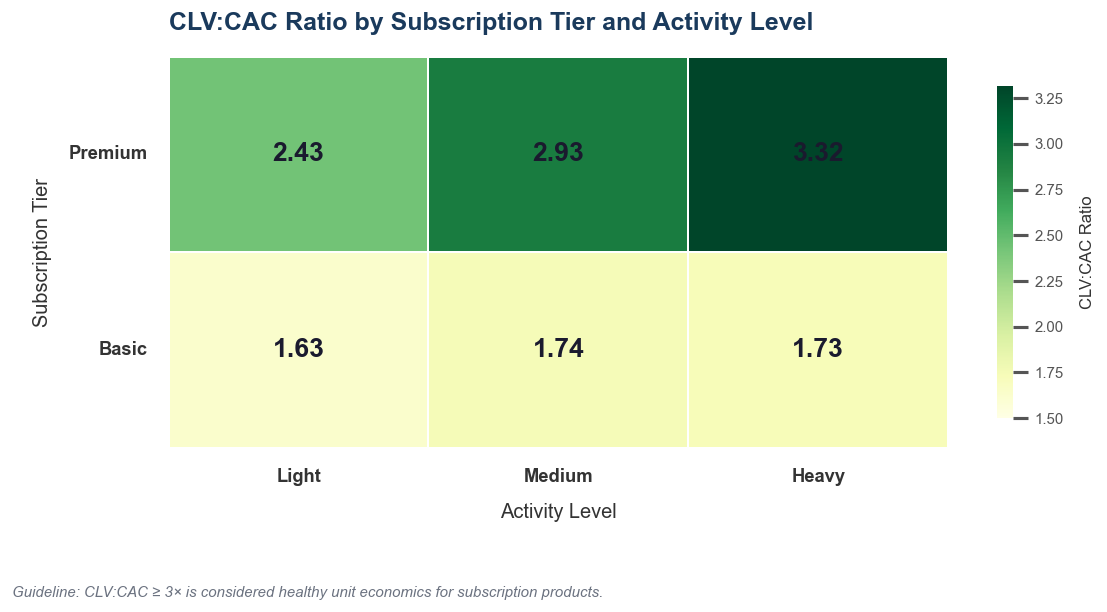

Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/fig_clv_cac_heatmap.png


In [8]:
# ── Cell 5b: CLV:CAC heatmap ───────────────────────────────────────────────────
# Maps each tier × activity segment to its average CLV:CAC ratio.
# Rule of thumb: CLV:CAC ≥ 3× is considered healthy for a subscription product.

clv_cac_pivot = (
    users
    .groupby(['subscription_tier', 'activity_level'])['clv_to_cac_ratio']
    .mean()
    .unstack()
    .reindex(index=['Premium', 'Basic'], columns=['Light', 'Medium', 'Heavy'])
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

sns.heatmap(
    clv_cac_pivot,
    annot=True,
    fmt='.2f',
    cmap='YlGn',
    linewidths=1.2,
    linecolor='white',
    vmin=1.5,
    ax=ax,
    annot_kws={'size': 16, 'weight': 'bold', 'color': '#1a1a2e'},
    cbar_kws={'label': 'CLV:CAC Ratio', 'shrink': 0.85},
)

ax.set_title(
    'CLV:CAC Ratio by Subscription Tier and Activity Level',
    fontsize=15, fontweight='bold', pad=16, color=PALETTE['navy'], loc='left'
)
ax.set_xlabel('Activity Level', fontsize=12, labelpad=10, color='#333333')
ax.set_ylabel('Subscription Tier', fontsize=12, labelpad=10, color='#333333')
ax.tick_params(left=False, bottom=False, labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold', color='#333333')
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold', color='#333333', rotation=0)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label('CLV:CAC Ratio', fontsize=10, labelpad=10)

# Threshold footnote
fig.text(
    0.02, -0.05,
    'Guideline: CLV:CAC ≥ 3× is considered healthy unit economics for subscription products.',
    fontsize=9, color=PALETTE['dgrey'], style='italic'
)

plt.tight_layout(pad=1.5)
plt.savefig(f'{OUTPUT_DIR}/fig_clv_cac_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/fig_clv_cac_heatmap.png')

---
## 6. Visualizations

Four charts are produced for use in the written report and slide deck. Each chart is saved to `outputs/` at publication quality (150 dpi).

| Chart | File | Report location |
|---|---|---|
| CLV distribution + segment boxes + payback bar + retention scatter | `fig_clv_panel.png` | Analytics section |
| Payback period CDF by tier | `fig_payback_cdf.png` | Analytics section |

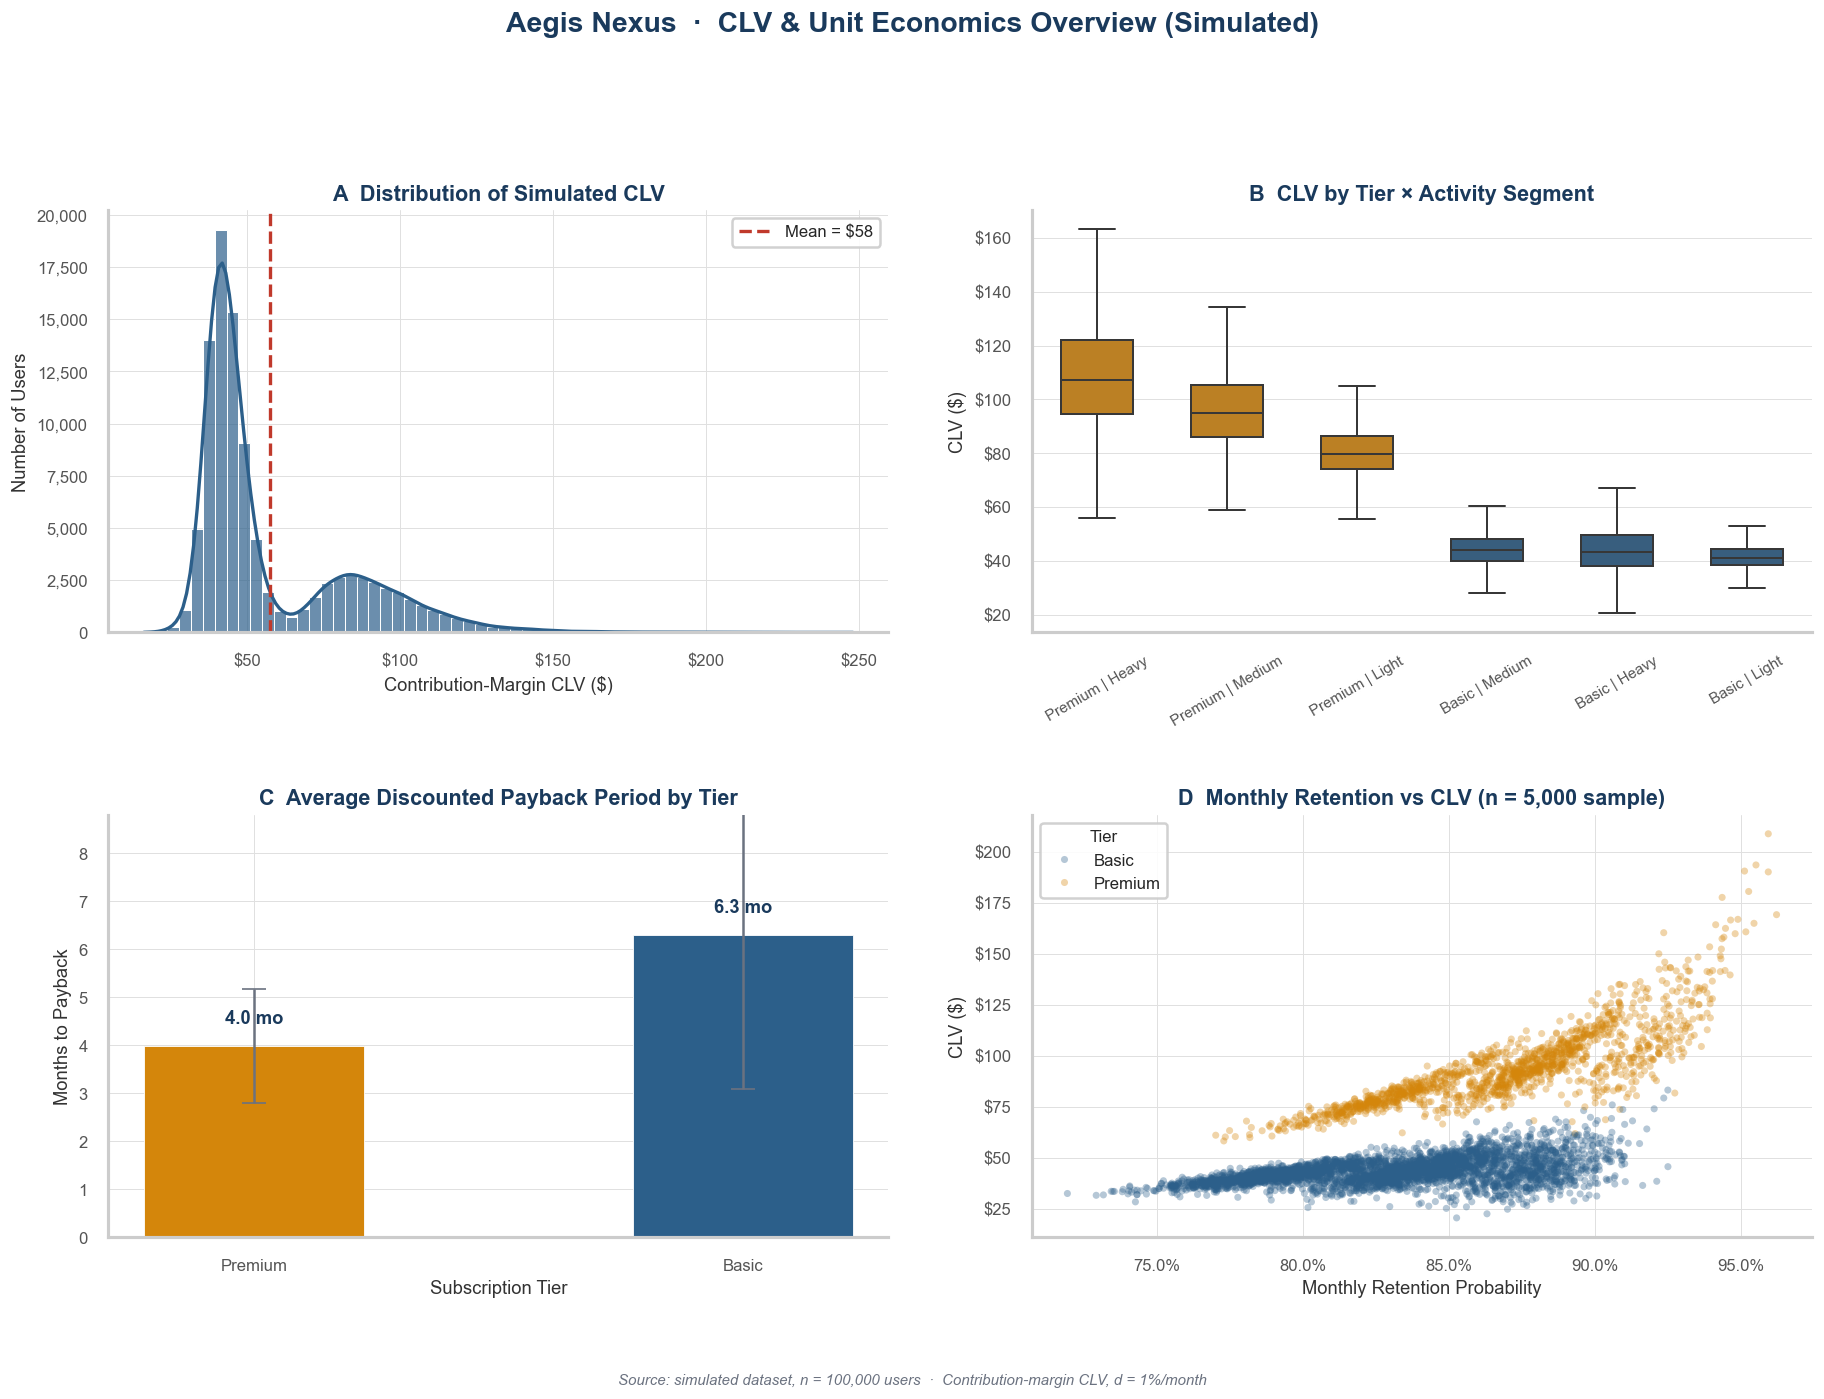

Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/fig_clv_panel.png


In [9]:
# ── Cell 6a: 2×2 panel — core CLV analytics ───────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Aegis Nexus  ·  CLV & Unit Economics Overview (Simulated)',
    fontsize=17, fontweight='bold', y=1.02, color=PALETTE['navy']
)

# ── Panel A: CLV distribution ─────────────────────────────────────────────────
sns.histplot(
    users['clv'], bins=60, kde=True,
    color=PALETTE['steel'], alpha=0.70,
    line_kws={'linewidth': 2}, ax=axes[0, 0]
)
axes[0, 0].axvline(
    users['clv'].mean(), color=PALETTE['rose'], linestyle='--', linewidth=2,
    label=f"Mean = ${users['clv'].mean():.0f}"
)
axes[0, 0].legend(fontsize=10, framealpha=0.9)
axes[0, 0].set_title('A  Distribution of Simulated CLV',
                      fontweight='bold', fontsize=13, color=PALETTE['navy'])
axes[0, 0].set_xlabel('Contribution-Margin CLV ($)', fontsize=11)
axes[0, 0].set_ylabel('Number of Users', fontsize=11)
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Panel B: CLV by tier × activity ───────────────────────────────────────────
segment_plot = users.copy()
segment_plot['segment'] = segment_plot['subscription_tier'] + ' | ' + segment_plot['activity_level']
seg_order = (
    segment_plot.groupby('segment')['clv']
    .median()
    .sort_values(ascending=False)
    .index
)
seg_palette = {
    seg: TIER_COLORS['Premium'] if seg.startswith('Premium') else TIER_COLORS['Basic']
    for seg in seg_order
}
sns.boxplot(
    data=segment_plot, x='segment', y='clv',
    order=seg_order, palette=seg_palette,
    showfliers=False, linewidth=1.2,
    width=0.55, ax=axes[0, 1]
)
axes[0, 1].set_title('B  CLV by Tier × Activity Segment',
                      fontweight='bold', fontsize=13, color=PALETTE['navy'])
axes[0, 1].set_xlabel('', fontsize=11)
axes[0, 1].set_ylabel('CLV ($)', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=30, labelsize=9)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Panel C: Average payback by tier ──────────────────────────────────────────
payback_agg = (
    users.groupby('subscription_tier')['payback_months']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values('mean')
)
bar_colors = [TIER_COLORS[t] for t in payback_agg['subscription_tier']]
bars = axes[1, 0].bar(
    payback_agg['subscription_tier'],
    payback_agg['mean'],
    yerr=payback_agg['std'],
    color=bar_colors,
    capsize=7, error_kw={'linewidth': 1.5, 'ecolor': PALETTE['dgrey']},
    width=0.45, edgecolor='white', linewidth=0.5,
)
for bar, mean_val in zip(bars, payback_agg['mean']):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        mean_val + 0.4,
        f'{mean_val:.1f} mo',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        color=PALETTE['navy']
    )
axes[1, 0].set_title('C  Average Discounted Payback Period by Tier',
                      fontweight='bold', fontsize=13, color=PALETTE['navy'])
axes[1, 0].set_xlabel('Subscription Tier', fontsize=11)
axes[1, 0].set_ylabel('Months to Payback', fontsize=11)
axes[1, 0].set_ylim(0, payback_agg['mean'].max() * 1.40)

# ── Panel D: Retention vs CLV scatter ─────────────────────────────────────────
sampled = users.sample(5_000, random_state=SEED)
sns.scatterplot(
    data=sampled,
    x='monthly_retention_prob', y='clv',
    hue='subscription_tier',
    palette=TIER_COLORS,
    alpha=0.35, s=18, ax=axes[1, 1],
    edgecolor='none',
)
axes[1, 1].set_title('D  Monthly Retention vs CLV (n = 5,000 sample)',
                      fontweight='bold', fontsize=13, color=PALETTE['navy'])
axes[1, 1].set_xlabel('Monthly Retention Probability', fontsize=11)
axes[1, 1].set_ylabel('CLV ($)', fontsize=11)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1, 1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1, 1].legend(title='Tier', fontsize=10, title_fontsize=10)

fig.text(
    0.5, -0.02,
    'Source: simulated dataset, n = 100,000 users  ·  Contribution-margin CLV, d = 1%/month',
    ha='center', fontsize=9, color=PALETTE['dgrey'], style='italic'
)

plt.tight_layout(pad=2.0)
plt.savefig(f'{OUTPUT_DIR}/fig_clv_panel.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/fig_clv_panel.png')

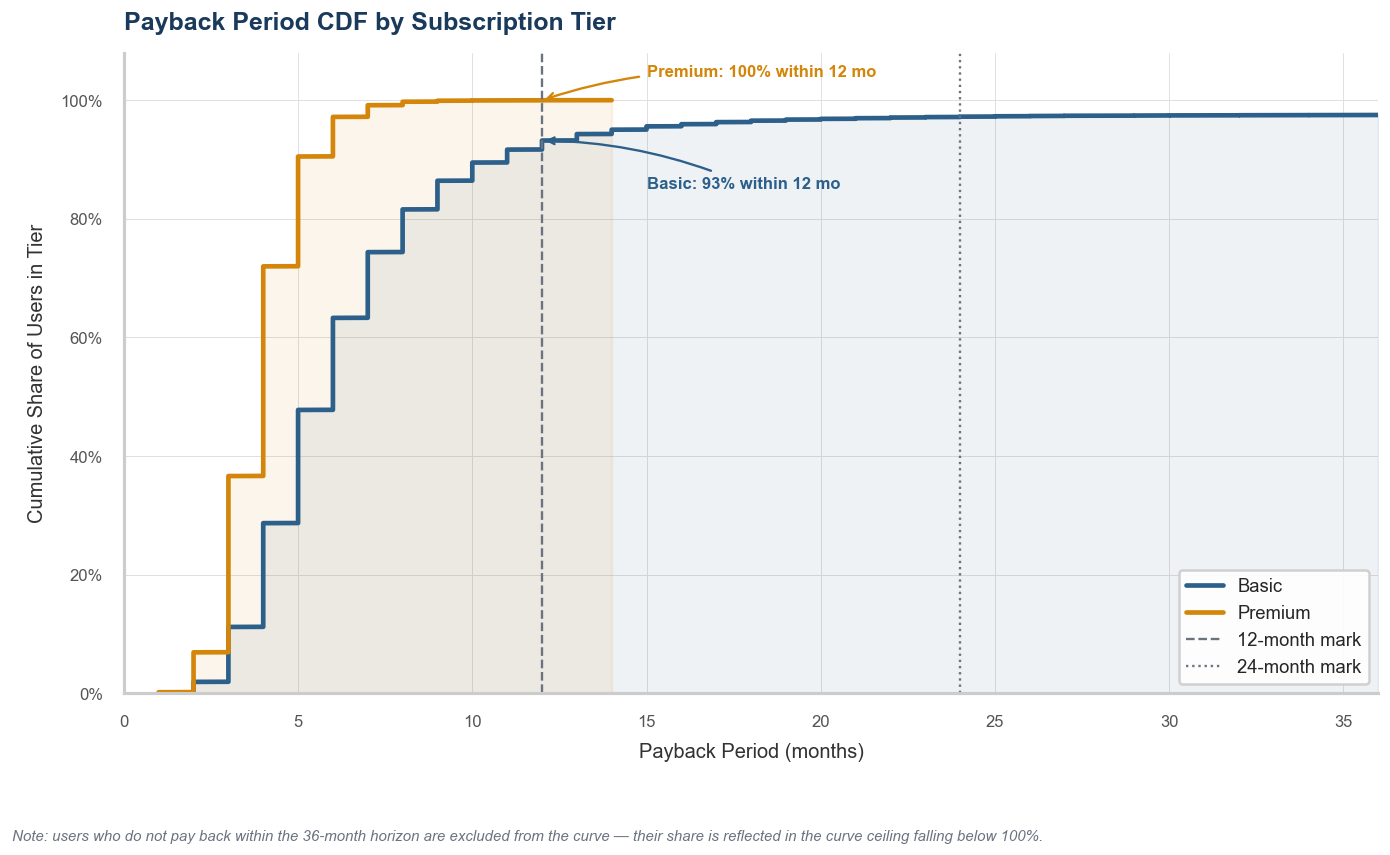

Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/fig_payback_cdf.png


In [10]:
# ── Cell 6b: Payback period CDF by subscription tier ─────────────────────────
# The CDF shows the DISTRIBUTION of payback risk — not just the mean.

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

for i, (tier, color) in enumerate(TIER_COLORS.items()):
    sub = (
        users.loc[users.subscription_tier == tier, 'payback_months']
        .dropna()
        .sort_values()
    )
    cdf = np.arange(1, len(sub) + 1) / users['subscription_tier'].eq(tier).sum()
    ax.plot(sub, cdf, label=tier, color=color, linewidth=2.8, solid_capstyle='round')
    ax.fill_between(sub, cdf, alpha=0.08, color=color)

# Reference lines
ax.axvline(12, color=PALETTE['dgrey'], linestyle='--', linewidth=1.4, label='12-month mark')
ax.axvline(24, color=PALETTE['dgrey'], linestyle=':',  linewidth=1.4, label='24-month mark')

# 12-month share annotations
for i, (tier, color) in enumerate(TIER_COLORS.items()):
    share_12 = users.loc[users.subscription_tier == tier, 'payback_months'].le(12).mean()
    offset_y = -0.08 if i == 0 else 0.04
    ax.annotate(
        f'{tier}: {share_12:.0%} within 12 mo',
        xy=(12, share_12),
        xytext=(15, share_12 + offset_y),
        fontsize=10, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.4,
                        connectionstyle='arc3,rad=0.1'),
    )

ax.set_xlabel('Payback Period (months)', fontsize=12, labelpad=8)
ax.set_ylabel('Cumulative Share of Users in Tier', fontsize=12, labelpad=8)
ax.set_title(
    'Payback Period CDF by Subscription Tier',
    fontsize=15, fontweight='bold', pad=14, color=PALETTE['navy'], loc='left'
)
ax.set_xlim(0, PAYBACK_HORIZON_MONTHS)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=11, framealpha=0.9)

fig.text(
    0.02, -0.04,
    'Note: users who do not pay back within the 36-month horizon are excluded from the curve'
    ' — their share is reflected in the curve ceiling falling below 100%.',
    fontsize=9, color=PALETTE['dgrey'], style='italic'
)

plt.tight_layout(pad=1.5)
plt.savefig(f'{OUTPUT_DIR}/fig_payback_cdf.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/fig_payback_cdf.png')

---
## 7. Sensitivity Analysis

The proposal committed to testing how CLV changes under different **churn/retention**, **infrastructure cost**, and **premium adoption** assumptions. The five scenarios below are designed to bound the range of plausible launch outcomes rather than to predict a single number.

| Scenario | Lever changed | Direction |
|---|---|---|
| Base case | — | — |
| Retention −3 pp | Monthly retention shifted down 3 percentage points for all users | Pessimistic |
| Retention +2 pp | Monthly retention shifted up 2 percentage points | Optimistic |
| Infrastructure cost +20% | All infra costs multiplied by 1.20 | Cost shock |
| Premium adoption rises to 35% | Tier mix reweighted; CLVs unchanged | Mix shift |

In [11]:
# ── Cell 7a: Sensitivity scenario table ───────────────────────────────────────

def portfolio_clv_with_mix(premium_share, basic_clv, premium_clv):
    """Weighted average portfolio CLV given a specified tier-mix premium share."""
    return (1 - premium_share) * basic_clv + premium_share * premium_clv


# Scenario definitions: (label, retention_shift_pp, infra_multiplier, premium_share)
scenarios = [
    ('Base case',                     0.00, 1.00, tier_mix['Premium']),
    ('Retention −3 pp',              -0.03, 1.00, tier_mix['Premium']),
    ('Retention +2 pp',               0.02, 1.00, tier_mix['Premium']),
    ('Infrastructure cost +20%',      0.00, 1.20, tier_mix['Premium']),
    ('Premium adoption rises to 35%', 0.00, 1.00, 0.35),
]

scenario_rows = []

for label, ret_shift, infra_mult, prem_share in scenarios:
    # Apply shocks to the base-case user-level vectors
    s_retention = np.clip(users['monthly_retention_prob'] + ret_shift, 0.55, 0.98)
    s_margin    = users['monthly_price'] - (users['monthly_infrastructure_cost'] * infra_mult)
    s_clv       = discounted_clv(s_margin, s_retention, MONTHLY_DISCOUNT_RATE)
    s_payback   = discounted_payback_months(
        s_margin.to_numpy(),
        s_retention.to_numpy(),
        users['cac'].to_numpy(),
        MONTHLY_DISCOUNT_RATE,
        PAYBACK_HORIZON_MONTHS,
    )

    basic_clv   = s_clv[users['subscription_tier'] == 'Basic'].mean()
    premium_clv = s_clv[users['subscription_tier'] == 'Premium'].mean()
    portfolio   = portfolio_clv_with_mix(prem_share, basic_clv, premium_clv)

    scenario_rows.append({
        'Scenario'              : label,
        'Portfolio avg CLV ($)' : round(portfolio, 2),
        'Basic avg CLV ($)'     : round(basic_clv, 2),
        'Premium avg CLV ($)'   : round(premium_clv, 2),
        'Net CLV after CAC ($)' : round(portfolio - users['cac'].mean(), 2),
        'Share payback ≤12 mo'  : f"{pd.Series(s_payback).le(12).mean():.1%}",
    })

scenario_table = pd.DataFrame(scenario_rows)
# Sort so base case is always first
scenario_table = pd.concat([
    scenario_table[scenario_table['Scenario'] == 'Base case'],
    scenario_table[scenario_table['Scenario'] != 'Base case'],
]).reset_index(drop=True)

display(scenario_table)

# Export for the appendix
scenario_table.to_csv(f'{OUTPUT_DIR}/table_sensitivity.csv', index=False)
print(f'Saved → {OUTPUT_DIR}/table_sensitivity.csv')

,Scenario,Portfolio avg CLV ($),Basic avg CLV ($),Premium avg CLV ($),Net CLV after CAC ($),Share payback ≤12 mo
0,Base case,57.52,43.38,93.88,28.28,95.1%
1,Retention −3 pp,47.71,36.87,75.61,18.48,88.3%
2,Retention +2 pp,67.05,49.27,112.78,37.81,97.6%
3,Infrastructure cost +20%,50.47,37.91,82.78,21.24,85.3%
4,Premium adoption rises to 35%,61.05,43.38,93.88,31.82,95.1%


Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_sensitivity.csv


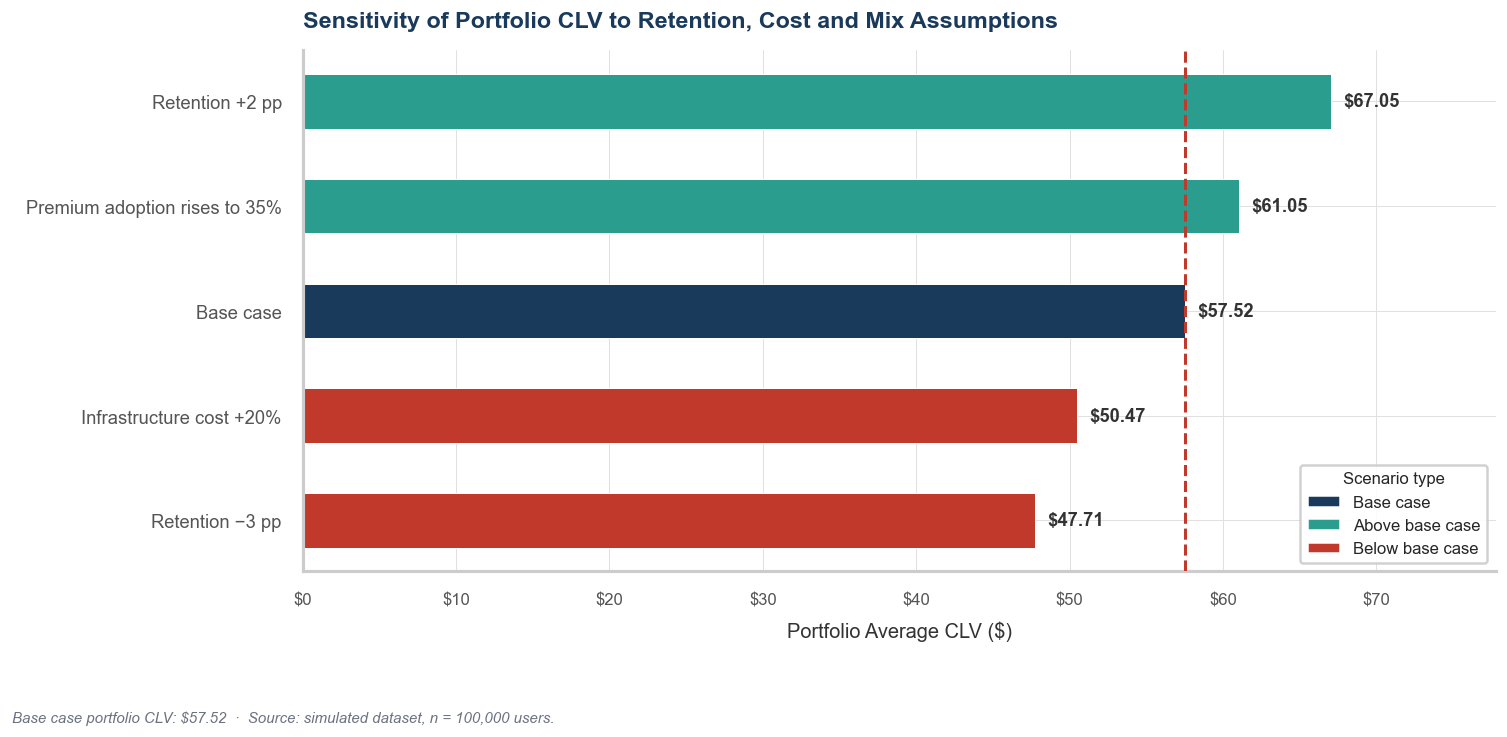

Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/fig_sensitivity.png


In [12]:
# ── Cell 7b: Tornado chart — sensitivity of portfolio CLV ─────────────────────

plot_df  = scenario_table.sort_values('Portfolio avg CLV ($)', ascending=True).copy()
base_clv = scenario_table.loc[
    scenario_table['Scenario'] == 'Base case', 'Portfolio avg CLV ($)'
].values[0]

# Colour: navy = base case; teal = above base; rose = below base
def _bar_color(scenario, value):
    if scenario == 'Base case':
        return PALETTE['navy']
    return PALETTE['teal'] if value >= base_clv else PALETTE['rose']

colors = [_bar_color(s, v)
          for s, v in zip(plot_df['Scenario'], plot_df['Portfolio avg CLV ($)'])]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

bars = ax.barh(
    plot_df['Scenario'],
    plot_df['Portfolio avg CLV ($)'],
    color=colors,
    edgecolor='white',
    linewidth=0.6,
    height=0.52,
)

# Value labels on each bar
max_val = plot_df['Portfolio avg CLV ($)'].max()
for bar, val in zip(bars, plot_df['Portfolio avg CLV ($)']):
    ax.text(
        val + max_val * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.2f}',
        va='center', fontsize=11, fontweight='bold', color='#333333'
    )

# Base-case reference line
ax.axvline(
    base_clv, color=PALETTE['rose'], linestyle='--', linewidth=1.8,
    zorder=3
)

ax.set_title(
    'Sensitivity of Portfolio CLV to Retention, Cost and Mix Assumptions',
    fontsize=14, fontweight='bold', pad=14, color=PALETTE['navy'], loc='left'
)
ax.set_xlabel('Portfolio Average CLV ($)', fontsize=12, labelpad=8)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, max_val * 1.16)
ax.tick_params(axis='y', labelsize=11)

# Colour legend
legend_elements = [
    Patch(facecolor=PALETTE['navy'], label='Base case'),
    Patch(facecolor=PALETTE['teal'], label='Above base case'),
    Patch(facecolor=PALETTE['rose'], label='Below base case'),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.9,
          loc='lower right', title='Scenario type', title_fontsize=10)

fig.text(
    0.02, -0.05,
    f'Base case portfolio CLV: ${base_clv:,.2f}  ·  '
    'Source: simulated dataset, n = 100,000 users.',
    fontsize=9, color=PALETTE['dgrey'], style='italic'
)

plt.tight_layout(pad=1.5)
plt.savefig(f'{OUTPUT_DIR}/fig_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/fig_sensitivity.png')

---
## 8. Launch Implications

This section translates the simulation outputs into **actionable marketing decisions**. The notebook's purpose is not to prove Aegis Nexus will succeed, but to set disciplined acquisition and retention guardrails before the first dollar of marketing budget is spent.

---

### AI in Marketing — Roles, Data Sources, and Human-in-the-Loop Design

The launch plan places AI in three distinct roles. The table below makes explicit (i) what data each AI system consumes, (ii) what it does automatically, and (iii) where human judgment is required before action is taken.

| Marketing Function | AI Role | Data Sources | Automated | Human-in-the-Loop |
|---|---|---|---|---|
| **Paid acquisition / bid optimisation** | AI optimises CPI bids within per-segment CAC ceilings | Impression-level auction data; in-app event signals (install, trial start, subscription); segment labels (tier × activity proxy) | Real-time bid adjustments within approved ceiling; creative rotation; budget pacing | Marketers set the maximum acceptable CAC ceiling per segment (derived from CLV:CAC guardrails in Cell 8c); any ceiling change requires human approval |
| **Ad creative generation** | Generative AI produces playable-ad variants (copy, visual themes, demo scenarios) | Historical CTR/CVR by creative; brand guidelines; competitor creative signals | Generation of A/B test variants; auto-rejection of low-CTR creatives after minimum impression threshold | Human creative director approves all new concepts before live deployment; final selection of winning variant is a human decision |
| **Retention & churn management** | Churn prediction model scores each subscriber monthly; triggers automated win-back or upgrade nudges | In-app session data (play hours, frequency, last-active); subscription age; tier; device specs | Automated push notifications / in-app offers when churn probability exceeds threshold; threshold calibrated monthly | Human sets churn probability threshold and offer parameters (discount depth, timing); model flags high-value at-risk users (Premium \| Heavy) for manual account review |

**Judgment boundary principle**: AI operates within guardrails set by humans. No AI system in this launch plan has authority to increase the CAC ceiling, change pricing, or approve a creative concept unilaterally. The CLV:CAC ratios produced in this notebook are the quantitative foundation for those guardrails (see Cell 8c).


In [13]:
# ── Cell 8a: Plain-English launch implications ─────────────────────────────────

best_seg    = segment_summary.reset_index().iloc[0]    # highest avg CLV segment
worst_seg   = segment_summary.reset_index().iloc[-1]   # lowest avg CLV segment
base_row    = scenario_table.loc[scenario_table['Scenario'] == 'Base case'].iloc[0]
best_scen   = scenario_table.sort_values('Portfolio avg CLV ($)', ascending=False).iloc[0]

avg_clv     = users['clv'].mean()
avg_cac     = users['cac'].mean()
avg_net_clv = users['net_clv_after_cac'].mean()
pct_12m     = users['payback_months'].le(12).mean()
pct_24m     = users['payback_months'].le(24).mean()

implications = [
    ('Acquisition guardrail',
     f'Average contribution-margin CLV = ${avg_clv:.2f} vs average CAC = ${avg_cac:.2f}. '
     f'Net CLV after CAC = ${avg_net_clv:.2f}. '
     f'The maximum sustainable CAC at launch is approximately ${avg_clv:.0f}/user. '
     f'Spending above this level requires either higher retention or lower infra costs to remain profitable.'),

    ('Segment priority',
     f"Prioritise '{best_seg['subscription_tier']} | {best_seg['activity_level']}' users at launch: "
     f"avg CLV = ${best_seg['avg_clv']:.2f}, avg net CLV = ${best_seg['avg_net_clv']:.2f}, "
     f"CLV:CAC = {best_seg['avg_clv_cac']:.2f}×. "
     f"Apply tighter CAC guardrails to '{worst_seg['subscription_tier']} | {worst_seg['activity_level']}' "
     f"(avg CLV = ${worst_seg['avg_clv']:.2f}, CLV:CAC = {worst_seg['avg_clv_cac']:.2f}×)."),

    ('Payback discipline',
     f'{pct_12m:.1%} of acquired users are expected to pay back within 12 months '
     f'and {pct_24m:.1%} within 24 months under base-case assumptions. '
     f'This means ~{1-pct_24m:.0%} of the cohort remains un-recovered after 2 years — '
     f'early campaigns should weight toward segments with shorter payback profiles.'),

    ('Tier emphasis',
     f"Premium users generate higher CLV (${tier_summary.loc['Premium', 'avg_clv']:.2f}) "
     f"than Basic users (${tier_summary.loc['Basic', 'avg_clv']:.2f}). "
     f"Increasing Premium share from {tier_mix['Premium']:.0%} to 35% improves portfolio CLV. "
     f"Consider playable-ad formats that self-select high-intent users toward the Premium CTA."),

    ('Retention as the key lever',
     f'A 3 pp drop in retention reduces portfolio CLV more than a 20% infra cost increase '
     f'(see sensitivity chart). This means retention investment — onboarding quality, '
     f'content freshness, latency performance — has a higher ROI than cost-cutting alone.'),
]

for heading, text in implications:
    print(f'▶  {heading}')
    print(f'   {text}')
    print()

# ── Slide-ready summary table ─────────────────────────────────────────────────
slide_ready = pd.DataFrame({
    'Metric': [
        'Average CLV (contribution-margin)',
        'Average CAC',
        'Average net CLV after CAC',
        'Average CLV:CAC ratio',
        'Share paying back within 12 months',
        'Priority segment',
        'Maximum sustainable CAC',
    ],
    'Value': [
        f"${avg_clv:.2f}",
        f"${avg_cac:.2f}",
        f"${avg_net_clv:.2f}",
        f"{users['clv_to_cac_ratio'].mean():.2f}×",
        f"{pct_12m:.1%}",
        f"{best_seg['subscription_tier']} | {best_seg['activity_level']}",
        f"${avg_clv:.0f} / user",
    ],
})

print('── Slide-ready summary ──')
display(slide_ready)

▶  Acquisition guardrail
   Average contribution-margin CLV = $57.52 vs average CAC = $29.24. Net CLV after CAC = $28.28. The maximum sustainable CAC at launch is approximately $58/user. Spending above this level requires either higher retention or lower infra costs to remain profitable.

▶  Segment priority
   Prioritise 'Premium | Heavy' users at launch: avg CLV = $110.44, avg net CLV = $75.35, CLV:CAC = 3.32×. Apply tighter CAC guardrails to 'Basic | Light' (avg CLV = $41.65, CLV:CAC = 1.63×).

▶  Payback discipline
   95.1% of acquired users are expected to pay back within 12 months and 98.0% within 24 months under base-case assumptions. This means ~2% of the cohort remains un-recovered after 2 years — early campaigns should weight toward segments with shorter payback profiles.

▶  Tier emphasis
   Premium users generate higher CLV ($93.88) than Basic users ($43.38). Increasing Premium share from 28% to 35% improves portfolio CLV. Consider playable-ad formats that self-select high-

,Metric,Value
0,Average CLV (contribution-margin),$57.52
1,Average CAC,$29.24
2,Average net CLV after CAC,$28.28
3,Average CLV:CAC ratio,2.02×
4,Share paying back within 12 months,95.1%
5,Priority segment,Premium | Heavy
6,Maximum sustainable CAC,$58 / user


In [14]:
# ── Cell 8c: Per-segment CAC bid ceilings — the concrete launch decision ────────
# This cell translates CLV:CAC ratios into actionable bid guardrails for the
# paid-acquisition team. The human-set minimum CLV:CAC floor determines which
# segments are eligible for paid acquisition and at what maximum CPI.
#
# Decision rule:
#   - CLV:CAC >= 2.0  → Priority acquisition target; AI bids up to CLV × 0.50
#   - CLV:CAC 1.5–2.0 → Secondary target; AI bids up to CLV × 0.35
#   - CLV:CAC < 1.5   → Exclude from paid acquisition; organic/referral only
#
# These thresholds are human-set. AI bid optimisers operate within these ceilings;
# they cannot override them.

CLV_CAC_FLOOR_PRIORITY   = 2.0   # human-set threshold: priority paid acquisition
CLV_CAC_FLOOR_SECONDARY  = 1.5   # human-set threshold: secondary paid acquisition
CAC_BUDGET_RATIO_PRIMARY = 0.50  # max CAC = CLV × this ratio (priority segments)
CAC_BUDGET_RATIO_SECOND  = 0.35  # max CAC = CLV × this ratio (secondary segments)

seg = segment_summary.reset_index()[[
    'subscription_tier', 'activity_level',
    'avg_clv', 'avg_cac', 'avg_clv_cac', 'avg_payback', 'pct_payback_12m'
]].copy()  # avg_payback now present after fix in cell-5a

def targeting_tier(clv_cac):
    if clv_cac >= CLV_CAC_FLOOR_PRIORITY:
        return 'Priority'
    elif clv_cac >= CLV_CAC_FLOOR_SECONDARY:
        return 'Secondary'
    else:
        return 'Exclude (organic only)'

def max_cac_ceiling(row):
    if row['targeting_tier'] == 'Priority':
        return round(row['avg_clv'] * CAC_BUDGET_RATIO_PRIMARY, 2)
    elif row['targeting_tier'] == 'Secondary':
        return round(row['avg_clv'] * CAC_BUDGET_RATIO_SECOND, 2)
    else:
        return 0.0

def channel_recommendation(row):
    if row['targeting_tier'] == 'Priority':
        return 'Playable ads (Meta/TikTok) + Google UAC — heavy-gaming genres'
    elif row['targeting_tier'] == 'Secondary':
        return 'Social display + retargeting — mid-core gaming audiences'
    else:
        return 'Organic app store + referral program only'

seg['targeting_tier']     = seg['avg_clv_cac'].apply(targeting_tier)
seg['max_cac_ceiling ($)'] = seg.apply(max_cac_ceiling, axis=1)
seg['channel_approach']   = seg.apply(channel_recommendation, axis=1)
seg['segment']            = seg['subscription_tier'] + ' | ' + seg['activity_level']

display_cols = [
    'segment', 'avg_clv', 'avg_clv_cac',
    'targeting_tier', 'max_cac_ceiling ($)', 'avg_payback', 'channel_approach'
]
targeting_table = seg[display_cols].sort_values('avg_clv', ascending=False)

print('── Per-Segment CAC Bid Ceilings and Targeting Decision ──')
print(f'   Human-set CLV:CAC floor (Priority)  : {CLV_CAC_FLOOR_PRIORITY}×')
print(f'   Human-set CLV:CAC floor (Secondary) : {CLV_CAC_FLOOR_SECONDARY}×')
print(f'   AI bid ceiling = CLV × {CAC_BUDGET_RATIO_PRIMARY} (Priority), '
      f'CLV × {CAC_BUDGET_RATIO_SECOND} (Secondary)\n')
display(targeting_table.reset_index(drop=True))

# Export for report appendix
targeting_table.to_csv(f'{OUTPUT_DIR}/table_targeting_decision.csv', index=False)
print(f'\nSaved → {OUTPUT_DIR}/table_targeting_decision.csv')

# ── Narrative summary printed for report copy-paste ───────────────────────────
priority_segs   = seg[seg['targeting_tier'] == 'Priority']['segment'].tolist()
secondary_segs  = seg[seg['targeting_tier'] == 'Secondary']['segment'].tolist()
excluded_segs   = seg[seg['targeting_tier'] == 'Exclude (organic only)']['segment'].tolist()
print('\n── Targeting narrative (for report analytics section) ──')
print(f'Priority segments (CLV:CAC ≥ {CLV_CAC_FLOOR_PRIORITY}×): {", ".join(priority_segs)}')
print(f'Secondary segments (CLV:CAC {CLV_CAC_FLOOR_SECONDARY}–{CLV_CAC_FLOOR_PRIORITY}×): {", ".join(secondary_segs)}')
print(f'Excluded from paid acquisition: {", ".join(excluded_segs) if excluded_segs else "None"}')
print('\nLaunch decision: AI bid optimisers are given per-segment CAC ceilings derived from')
print('CLV:CAC ratios. Humans set the CLV:CAC floor; AI operates within those bounds.')


── Per-Segment CAC Bid Ceilings and Targeting Decision ──
   Human-set CLV:CAC floor (Priority)  : 2.0×
   Human-set CLV:CAC floor (Secondary) : 1.5×
   AI bid ceiling = CLV × 0.5 (Priority), CLV × 0.35 (Secondary)



,segment,avg_clv,avg_clv_cac,targeting_tier,max_cac_ceiling ($),avg_payback,channel_approach
0,Premium | Heavy,110.44,3.32,Priority,55.22,4.86,Playable ads (Meta/TikTok) + Google UAC — heav...
1,Premium | Medium,96.76,2.93,Priority,48.38,3.92,Playable ads (Meta/TikTok) + Google UAC — heav...
2,Premium | Light,80.77,2.43,Priority,40.38,3.56,Playable ads (Meta/TikTok) + Google UAC — heav...
3,Basic | Medium,44.41,1.74,Secondary,15.54,6.20,Social display + retargeting — mid-core gaming...
4,Basic | Heavy,44.11,1.73,Secondary,15.44,8.32,Social display + retargeting — mid-core gaming...
5,Basic | Light,41.65,1.63,Secondary,14.58,5.27,Social display + retargeting — mid-core gaming...



Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_targeting_decision.csv

── Targeting narrative (for report analytics section) ──
Priority segments (CLV:CAC ≥ 2.0×): Premium | Heavy, Premium | Medium, Premium | Light
Secondary segments (CLV:CAC 1.5–2.0×): Basic | Medium, Basic | Heavy, Basic | Light
Excluded from paid acquisition: None

Launch decision: AI bid optimisers are given per-segment CAC ceilings derived from
CLV:CAC ratios. Humans set the CLV:CAC floor; AI operates within those bounds.


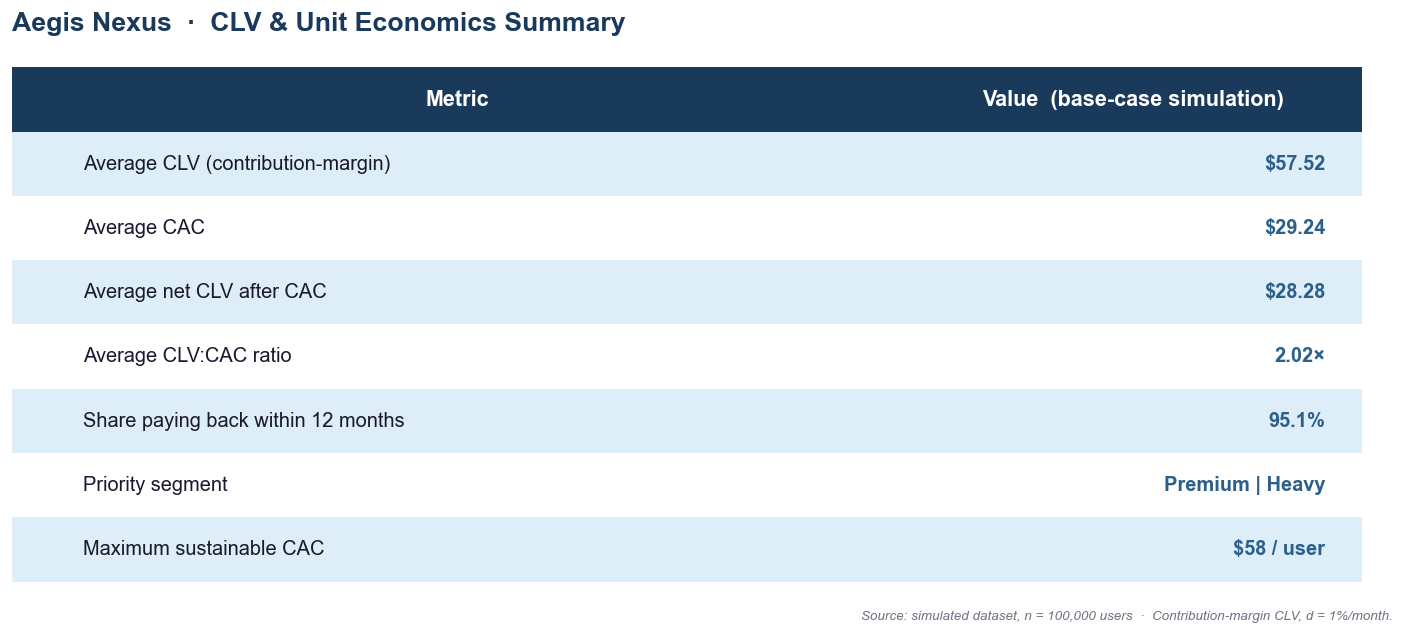

Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/slide_scorecard.png  (presentation-ready)


In [15]:
# ── Cell 8b: Presentation scorecard figure ────────────────────────────────────
# Designed for direct insertion into PowerPoint or Google Slides.

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')
ax.axis('off')

col_labels = ['Metric', 'Value  (base-case simulation)']
cell_text  = slide_ready.values.tolist()

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
    bbox=[0.0, 0.0, 1.0, 1.0],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)

col_widths = [0.66, 0.34]
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)
    cell.set_width(col_widths[col])
    cell.PAD = 0.08

    if row == 0:                   # header row
        cell.set_facecolor(PALETTE['navy'])
        cell.set_text_props(color='white', fontweight='bold', fontsize=13)
    elif row % 2 == 1:             # odd data rows — light tint
        cell.set_facecolor('#ddeef9')
        cell.set_text_props(color='#1a1a2e', fontsize=12)
    else:                          # even data rows — white
        cell.set_facecolor('white')
        cell.set_text_props(color='#1a1a2e', fontsize=12)

    if col == 1 and row > 0:       # value column: right-aligned, bold navy
        cell.set_text_props(ha='right', fontweight='bold', color=PALETTE['steel'])

tbl.scale(1.0, 2.2)

ax.set_title(
    'Aegis Nexus  ·  CLV & Unit Economics Summary',
    fontsize=16, fontweight='bold', pad=22, color=PALETTE['navy'], loc='left'
)
fig.text(
    0.99, 0.01,
    'Source: simulated dataset, n = 100,000 users  ·  Contribution-margin CLV, d = 1%/month.',
    ha='right', fontsize=8, color=PALETTE['dgrey'], style='italic'
)

plt.tight_layout(pad=1.5)
plt.savefig(f'{OUTPUT_DIR}/slide_scorecard.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/slide_scorecard.png  (presentation-ready)')

---
## 9. Limitations

1. **Simulated, not observed data.** All outputs depend on assumed parameter values. Results should be read as scenario-based guardrails, not post-launch forecasts. Assumption justification (market analogues, published UA benchmarks) is provided in the written report.

2. **Stationary retention model.** The model assumes a constant monthly retention probability for each user — no cohort effects, no content-driven churn spikes, no seasonality. A more realistic model would incorporate time-varying retention (e.g., higher churn in month 2 post-trial, recovery after major content drops).

3. **Fixed pricing.** Monthly prices are treated as constants. Pricing optimisation is discussed qualitatively in the written report but is not modelled here to keep the appendix scoped to one analytics module.

4. **No publisher revenue-sharing.** The contribution margin used here assumes Aegis Nexus captures 100% of the subscription fee. In practice, revenue-sharing with game publishers would reduce the net margin available to fund CAC, making the maximum sustainable CAC lower than the headline CLV.

5. **Independent user draws.** The simulation assumes users are drawn independently. In reality, network effects, referral programs, and social clustering could make user value correlated — either positively (viral acquisition) or negatively (churn contagion).

6. **AI model assumptions.** The churn prediction model and bid-optimisation system described in Section 8 are conceptual. Actual model performance (precision/recall of churn scores, bid win-rate curves) would depend on post-launch data that is not available at this stage. The CLV:CAC ceilings in Cell 8c are therefore conservative inputs derived from simulation, not calibrated model outputs. Human oversight of AI-driven decisions (as described in the human-in-the-loop table) is especially important during the first 6 months when training data is sparse.


In [16]:
# ── Cell 10: Export all summary tables to CSV ─────────────────────────────────
# These files allow the report to be written without re-running the notebook.
# The grader can cross-check any number in the written report against these CSVs.

exports = {
    'table_headline_metrics.csv'   : headline_metrics,
    'table_tier_summary.csv'       : tier_summary.reset_index().round(4),
    'table_activity_summary.csv'   : activity_summary.reset_index().round(4),
    'table_segment_summary.csv'    : segment_summary.reset_index().round(4),
    'table_sensitivity.csv'        : scenario_table,
    'table_targeting_decision.csv' : targeting_table.reset_index(drop=True),
}

for filename, df in exports.items():
    path = f'{OUTPUT_DIR}/{filename}'
    df.to_csv(path, index=False)
    print(f'Saved → {path}')

print(f'\nAll {len(exports)} tables saved to ./{OUTPUT_DIR}/')
print('\n── Final output inventory ──')
output_files = sorted(os.listdir(OUTPUT_DIR))
for f in output_files:
    size_kb = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    kind    = 'Figure' if f.endswith('.png') else 'Table '
    print(f'  {kind}  {f:<50}  ({size_kb:>6.1f} KB)')


Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_headline_metrics.csv
Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_tier_summary.csv
Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_activity_summary.csv
Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_segment_summary.csv
Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_sensitivity.csv
Saved → D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/table_targeting_decision.csv

All 6 tables saved to ./D:\2025-26 MMA Academics\RSM8542_AnalyticalMarketing\Individual Project\Outputs/

── Final output inventory ──
  Figure  fig_clv_cac_heatmap.png                             (  93.0 KB)
  Figure  fig_clv_panel.png                                   ( 530.0 KB)
  Figure  fig_payback_cdf.png     